# Planning a Radar Tracking Mission for a Research UAV: Filter Development across coordinate systems

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, atan, sin, cos, pi

### Part I. Mission build: Designing the Tracking Filter

### Trajectory generation

**True trajectory of UAV path**

Generating a true trajectory of the coordinates $𝒙_𝒊$ and $y_i$ of an UAV's motion. The trajectory
will consist of 26 points, starting with initial conditions $𝑥_0 = \frac{13500}{\sqrt{2}} m$. ,$y_0 = \frac{13500}{\sqrt{2}} m$., $𝑉_x = -50$ m/s, $𝑉_y = -45$ m/s. and a time
step $𝑇 = 2$ s.

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}^x T \\
V_i^x &= V_{i-1}^x \\
y_i &= y_{i-1} + V_{i-1}^y T \\
V_i^y &= V_{i-1}^y
\end{aligned}
$$

In [2]:
#generating_trajectory
steps=26
x_real=np.zeros(steps)
vx_real=np.zeros(steps)
y_real=np.zeros(steps)
vy_real=np.zeros(steps)
t=2
x_real[0]=13500/(sqrt(2))
y_real[0]=13500/(sqrt(2))
vx_real[0]=-50
vy_real[0]=-45
for i in range(1,steps):
    x_real[i]=x_real[i-1]+vx_real[i-1]*t
    vx_real[i]=vx_real[i-1]
    y_real[i]=y_real[i-1]+vy_real[i-1]*t
    vy_real[i]=vy_real[i-1]

**True trajectory of UAV path in polar coordinate system**

Generating the true values of range D (meters) and azimuth $\beta$ (radians)

$$
\begin{aligned}
D_i &= \sqrt{x_i^2 + y_i^2} \\
\beta_i &= \arctan\left(\frac{x_i}{y_i}\right)
\end{aligned}
$$

In [3]:
#trajectory_in_polar_coordinate_system
D_real=np.zeros(steps)
beta_real=np.zeros(steps)
for i in range(0,steps):
    D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
    beta_real[i] = atan(x_real[i]/y_real[i])

Let's plot the motion in polar coordinate system

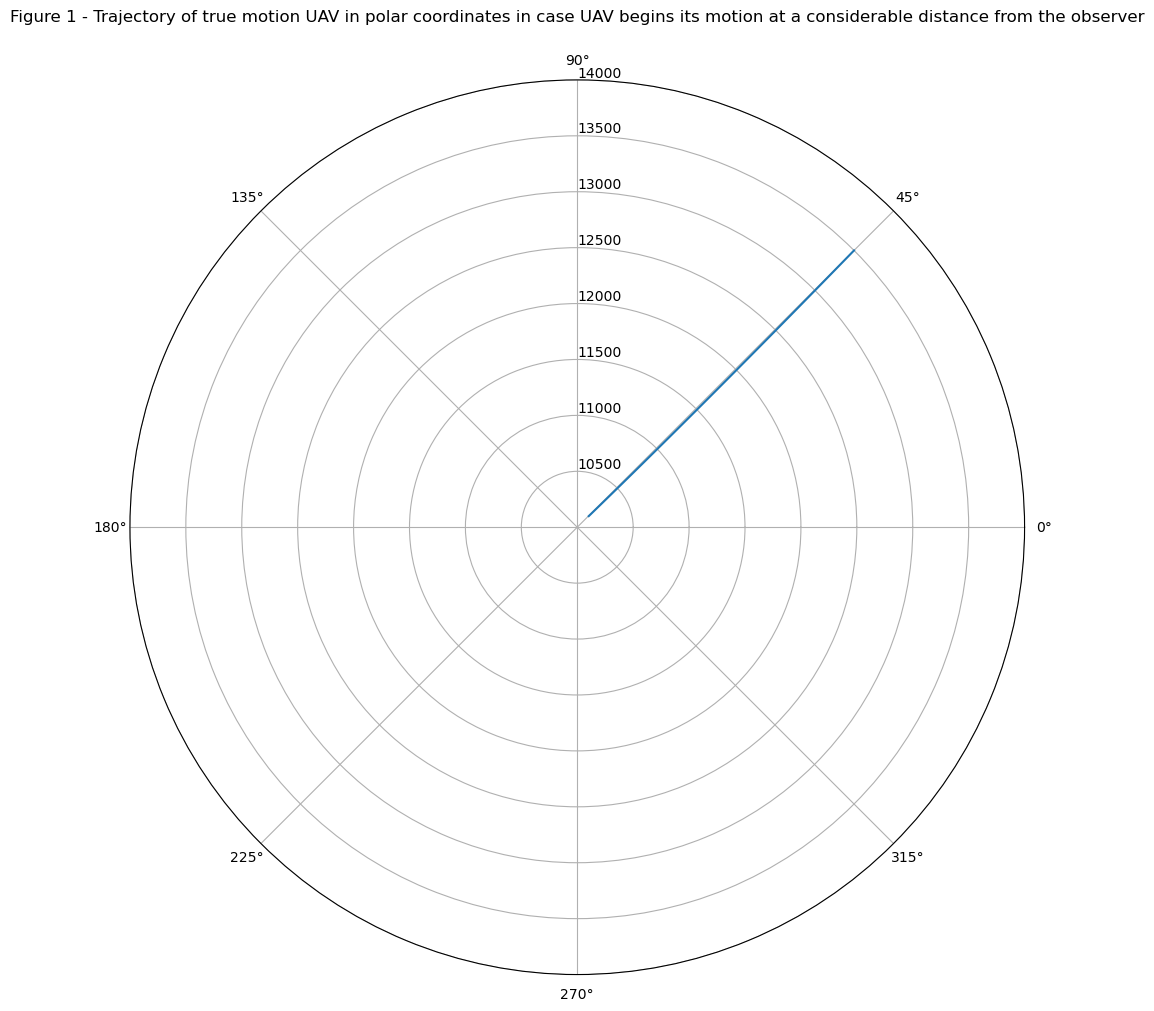

In [4]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real)
ax.grid(True)
ax.set_rlabel_position(90)
ax.set_ylim(10000,14000)
ax.set_title("Figure 1 - Trajectory of true motion UAV in polar coordinates in case UAV begins its motion at a considerable distance from the observer", va='bottom',pad=40)
plt.show()

**Measurements**  
Generate measured values as follows:  

\
\begin{align*}
D_{i}^{m} &= D_{i} + \eta _{i}^{D} \\
\beta _{i}^{m} &= \beta _{i} + \eta _{i}^{\beta}
\end{align*}
\
$\eta _{i}^{D}$ and $\eta _{i}^{\beta }$ are variances of the measurement noises $\sigma _{D}$=20 m and $\sigma _{\beta}$ = 0.02 rad

In [5]:
#generating_measurements_of_polar
D=np.zeros(steps)
beta=np.zeros(steps)
for i in range(0,steps):
    D[i]=D_real[i]+np.random.normal(0,20)
    beta[i]=beta_real[i]+np.random.normal(0,0.02)

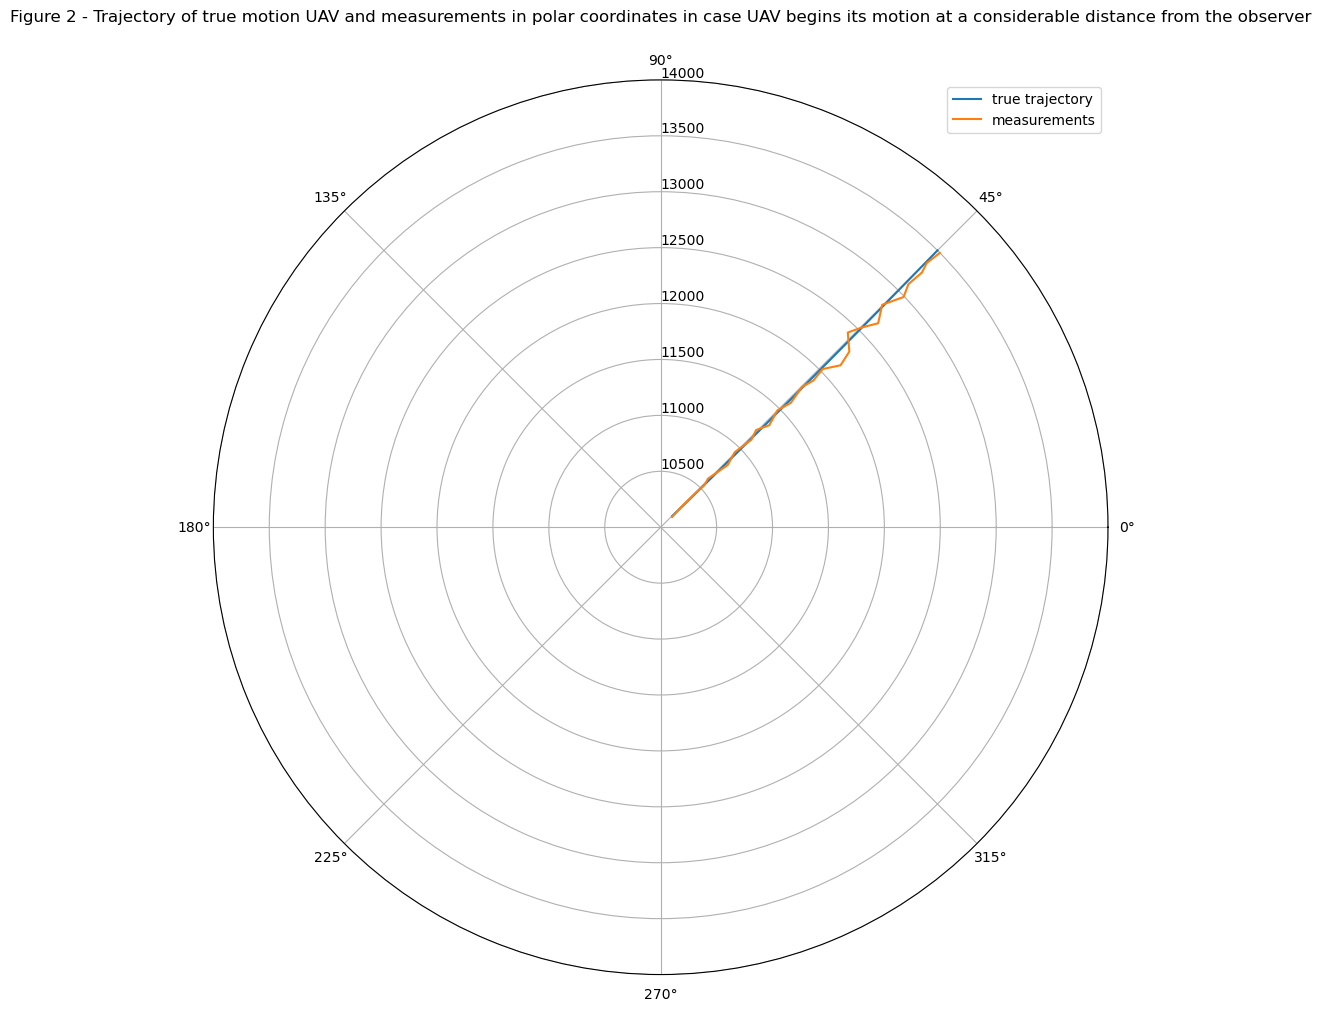

In [6]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trajectory')
ax.plot(beta, D, label='measurements')
ax.grid(True)
ax.legend()
ax.set_ylim(10000,14000)
ax.set_rlabel_position(90) 
ax.set_title("Figure 2 - Trajectory of true motion UAV and measurements in polar coordinates in case UAV begins its motion at a considerable distance from the observer", va='bottom',pad=40)
plt.show()

**Pseudo-measurements**  
Transform polar coordinates to Cartesian coordinates

In [7]:
x=np.zeros(steps)
y=np.zeros(steps)
for i in range(0,steps):
    x[i]=D[i]*sin(beta[i])
    y[i]=D[i]*cos(beta[i])

Create the measurement vector z from pseudo-measurements of coordinates x and y

In [8]:
z = np.zeros((len(x), 2, 1))
for i in range(len(x)):
    z[i] = np.array([[x[i]], [y[i]]])

**Kalman Filter**  
Let's develop Kalman Filter algorithm

In [9]:
#transition matrix
fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
#observation matrix
h=np.matrix([[1,0,0,0],[0,0,1,0]])
#state vector
X = np.zeros((len(x_real), 4, 1))
#Initial filtered estimate
X[0]=np.matrix([[40000],[-20],[40000],[-20]])
#Filtration error covariance matrix
P=np.zeros((steps, 4, 4))
P[0]=np.matrix([[10**10, 0,0,0], [0, 10**10,0,0],[0,0,10**10,0],[0,0,0,10**10]])
D_pred=np.zeros(steps)
D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
beta_pred=np.zeros(steps)
beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
D_filt=np.zeros(steps)
D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
beta_filt=np.zeros(steps)
beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
#Covariance matrix
R=np.zeros((steps, 2, 2))
for i in range(0,steps):
    R[i]=np.matrix([[sin(beta[i])**2 * 20**2 + D[i]**2 *cos(beta[i])**2*0.02**2, sin(beta[i])*cos(beta[i])*(20**2-D[i]**2*0.02**2)], [sin(beta[i])*cos(beta[i])*(20**2-D[i]**2*0.02**2), cos(beta[i])**2*20**2+D[i]**2*sin(beta[i])**2*0.02**2]])
K = np.zeros((steps, 4, 2))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)
    D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
    beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
    #step of filtration
    E=h@P[i]@h.T + R[i]
    K[i]=P[i]@h.T@np.linalg.inv(E)
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(4)-K[i]@h)@P[i]
    D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
    beta_filt[i]=atan(X[i,0,0]/X[i,2,0])

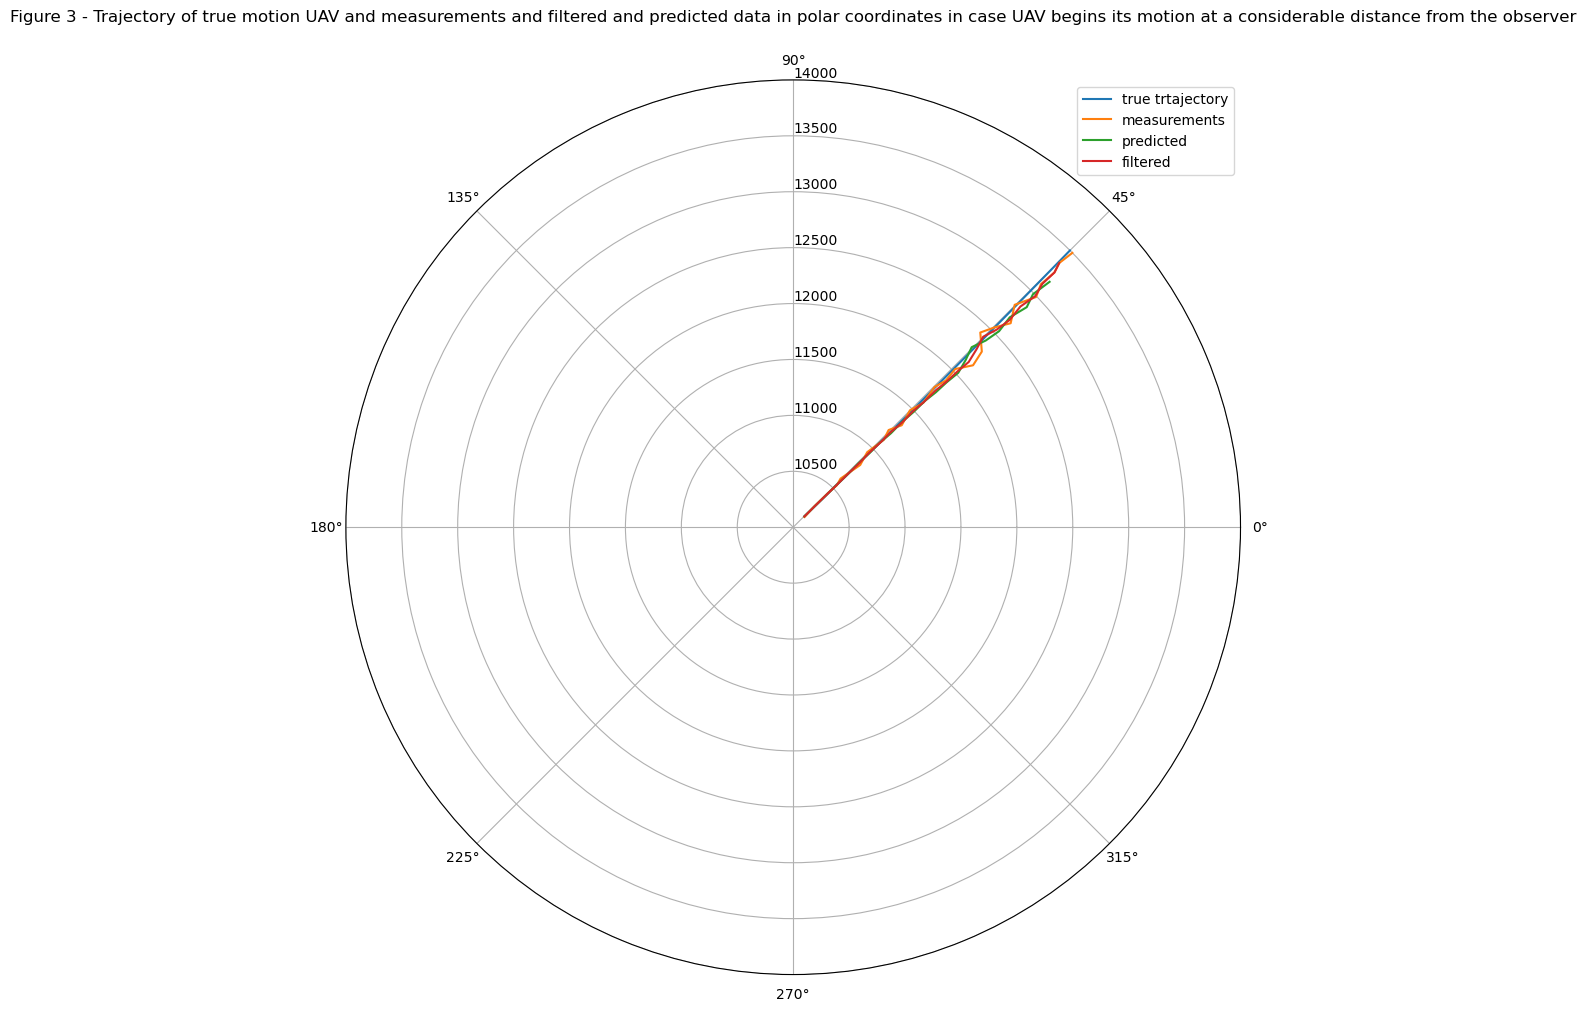

In [10]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred[3:], D_pred[3:], label='predicted')
ax.plot(beta_filt[1:], D_filt[1:], label='filtered')
ax.grid(True)
ax.legend()
ax.set_ylim(10000,14000)
ax.set_rlabel_position(90) 
ax.set_title("Figure 3 - Trajectory of true motion UAV and measurements and filtered and predicted data in polar coordinates in case UAV begins its motion at a considerable distance from the observer", va='bottom',pad=40)
plt.show()

Let's zoom a plot

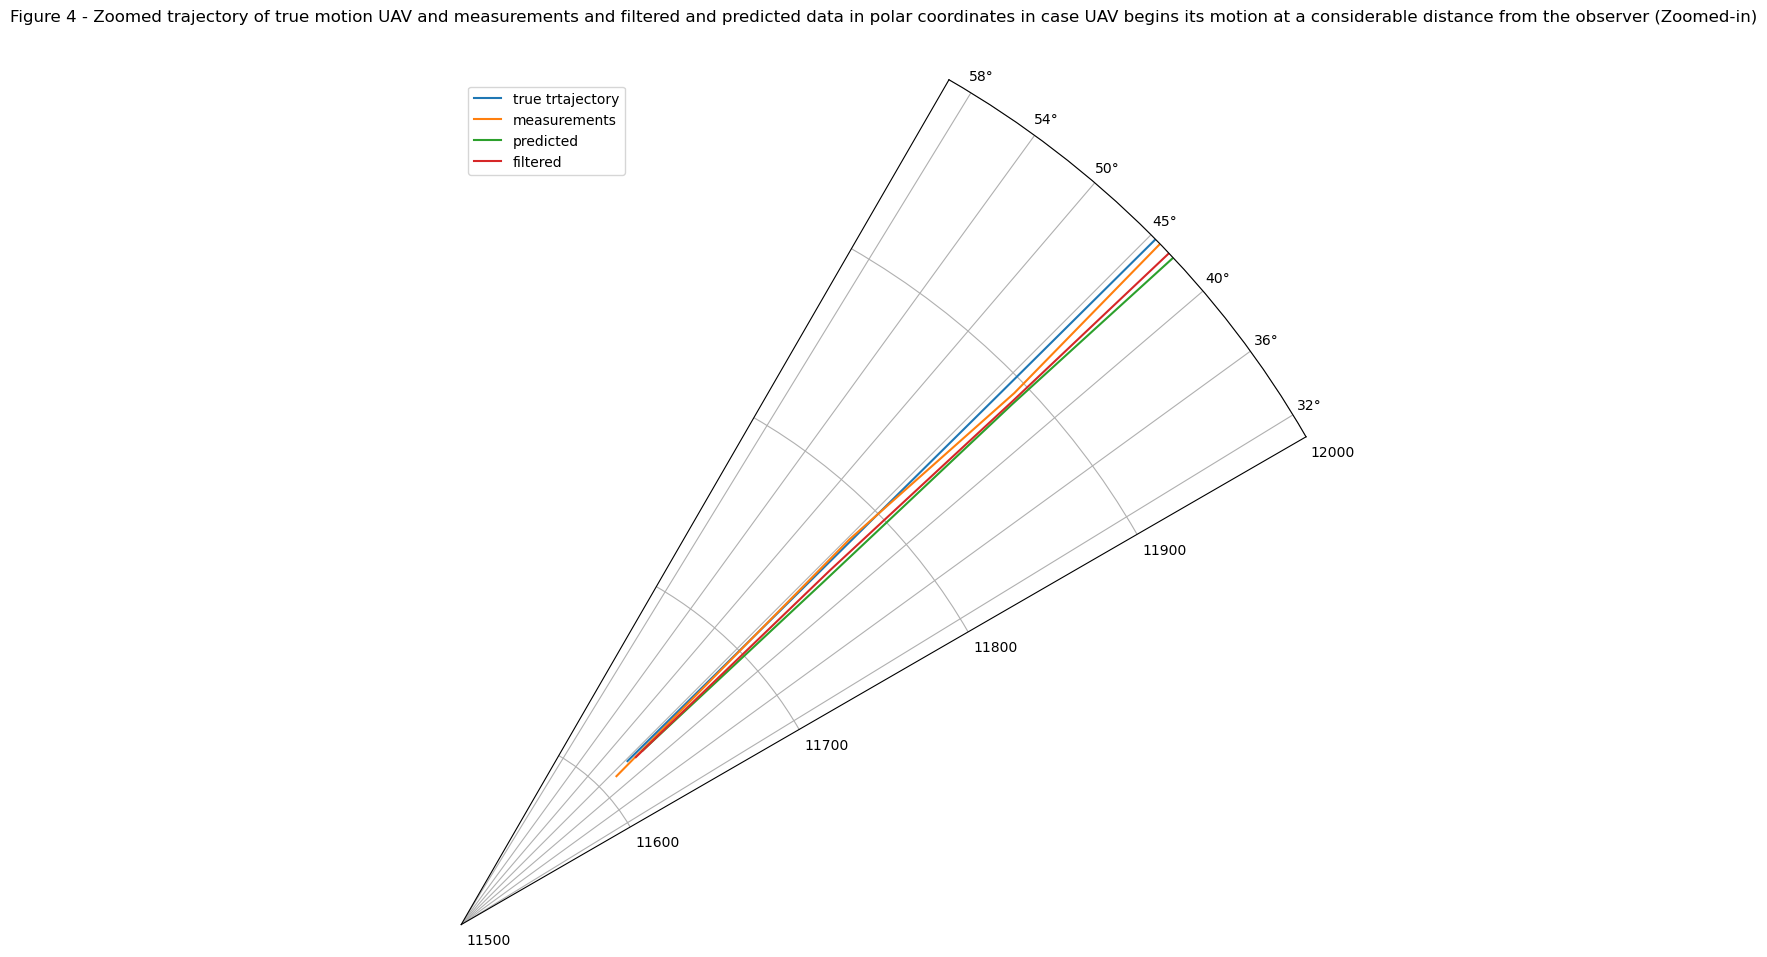

In [11]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_ylim(11500,12000)
ax.set_xlim(pi/6,pi/3)
ax.set_rlabel_position(90) 
ax.set_title("Figure 4 - Zoomed trajectory of true motion UAV and measurements and filtered and predicted data in polar coordinates in case UAV begins its motion at a considerable distance from the observer (Zoomed-in)", va='bottom',pad=40)
plt.show()

As we can see, the Kalman filter stabilizes well and filters data efficiently when translating the coordinate system.

### Part II. Mission Check: Stress-Testing the Filter

Run the Kalman Filter algorithm for M=500 iterations

In [12]:
#calculate error
M=500
steps=26
errordp=np.zeros((M,steps))
errorbp=np.zeros((M,steps))
fin_errdp=np.zeros(steps)
fin_errbp=np.zeros(steps)
errordf=np.zeros((M,steps))
errorbf=np.zeros((M,steps))
fin_errdf=np.zeros(steps)
fin_errbf=np.zeros(steps)
gain=np.zeros((M,steps))
fin_gain = np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=26
    x_real=np.zeros(steps)
    vx_real=np.zeros(steps)
    y_real=np.zeros(steps)
    vy_real=np.zeros(steps)
    t=2
    x_real[0]=13500/(sqrt(2))
    y_real[0]=13500/(sqrt(2))
    vx_real[0]=-50
    vy_real[0]=-45
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+vx_real[i-1]*t
        vx_real[i]=vx_real[i-1]
        y_real[i]=y_real[i-1]+vy_real[i-1]*t
        vy_real[i]=vy_real[i-1]
    #trajectory_in_polar_coordinate_system
    D_real=np.zeros(steps)
    beta_real=np.zeros(steps)
    for i in range(0,steps):
        D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
        beta_real[i] = atan(x_real[i]/y_real[i])
    #generating_measurements_of_polar
    D=np.zeros(steps)
    beta=np.zeros(steps)
    for i in range(0,steps):
        D[i]=D_real[i]+np.random.normal(0,20)
        beta[i]=beta_real[i]+np.random.normal(0,0.02)
    x=np.zeros(steps)
    y=np.zeros(steps)
    for i in range(0,steps):
        x[i]=D[i]*sin(beta[i])
        y[i]=D[i]*cos(beta[i])
    z = np.zeros((len(x), 2, 1))
    for i in range(len(x)):
        z[i] = np.array([[x[i]], [y[i]]])
    #transition matrix
    fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
    #observation matrix
    h=np.matrix([[1,0,0,0],[0,0,1,0]])
    #state vector
    X = np.zeros((len(x_real), 4, 1))
    #Initial filtered estimate
    X[0]=np.matrix([[40000],[-20],[40000],[-20]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 4, 4))
    P[0]=np.matrix([[10**10, 0,0,0], [0, 10**10,0,0],[0,0,10**10,0],[0,0,0,10**10]])
    D_pred=np.zeros(steps)
    D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_pred=np.zeros(steps)
    beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
    D_filt=np.zeros(steps)
    D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_filt=np.zeros(steps)
    beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
    #Covariance matrix
    R=np.zeros((steps, 2, 2))
    for i in range(0,steps):
        R[i]=np.matrix([[sin(beta[i])**2 * 20**2 + D[i]**2 *cos(beta[i])**2*0.02**2, sin(beta[i])*cos(beta[i])*(20**2-D[i]**2*0.02**2)], [sin(beta[i])*cos(beta[i])*(20**2-D[i]**2*0.02**2), cos(beta[i])**2*20**2+D[i]**2*sin(beta[i])**2*0.02**2]])
    for i in range(1,steps):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)
        D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
        #step of filtration
        E=h@P[i]@h.T + R[i]
        K[i]=P[i]@h.T@np.linalg.inv(E)
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(4)-K[i]@h)@P[i]
        D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
        gain[o, i] = K[i, 0, 0]
    for k in range(2,steps):
        errordp[o,k]=(D_real[k]-D_pred[k])**2
        errorbp[o,k]=(beta_real[k]-beta_pred[k])**2
        errordf[o,k]=(D_real[k]-D_filt[k])**2
        errorbf[o,k]=(beta_real[k]-beta_filt[k])**2
for i in range(steps):
    for j in range(M):
        fin_gain[i] += gain[j, i]/M
        fin_errdp[i]=fin_errdp[i]+((1/(M-1))*errordp[j,i])
        fin_errbp[i]=fin_errbp[i]+((1/(M-1))*errorbp[j,i])
        fin_errdf[i]=fin_errdf[i]+((1/(M-1))*errordf[j,i])
        fin_errbf[i]=fin_errbf[i]+((1/(M-1))*errorbf[j,i])
    fin_errdp[i]=sqrt(fin_errdp[i])/20
    fin_errbp[i]=sqrt(fin_errbp[i])/0.02
    fin_errdf[i]=sqrt(fin_errdf[i])/20
    fin_errbf[i]=sqrt(fin_errbf[i])/0.02

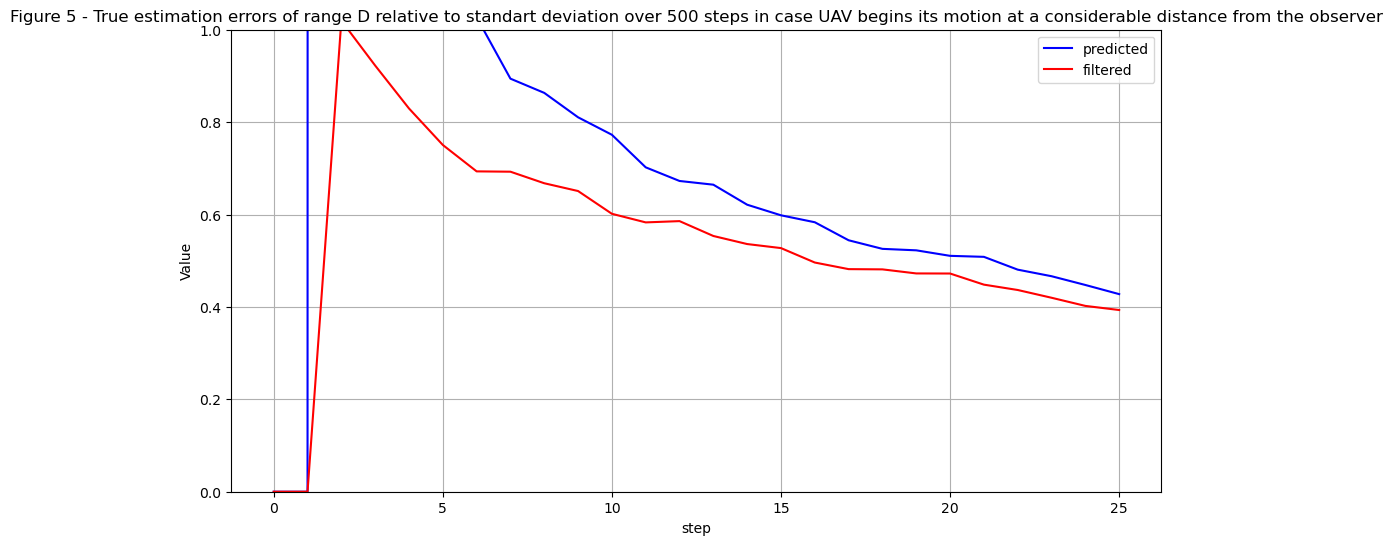

In [13]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errdp, color="blue", label='predicted')
plt.plot(fin_errdf, color="red", label='filtered')
plt.title('Figure 5 - True estimation errors of range D relative to standart deviation over 500 steps in case UAV begins its motion at a considerable distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.ylim(0,1)
plt.grid()
plt.legend()
plt.show()

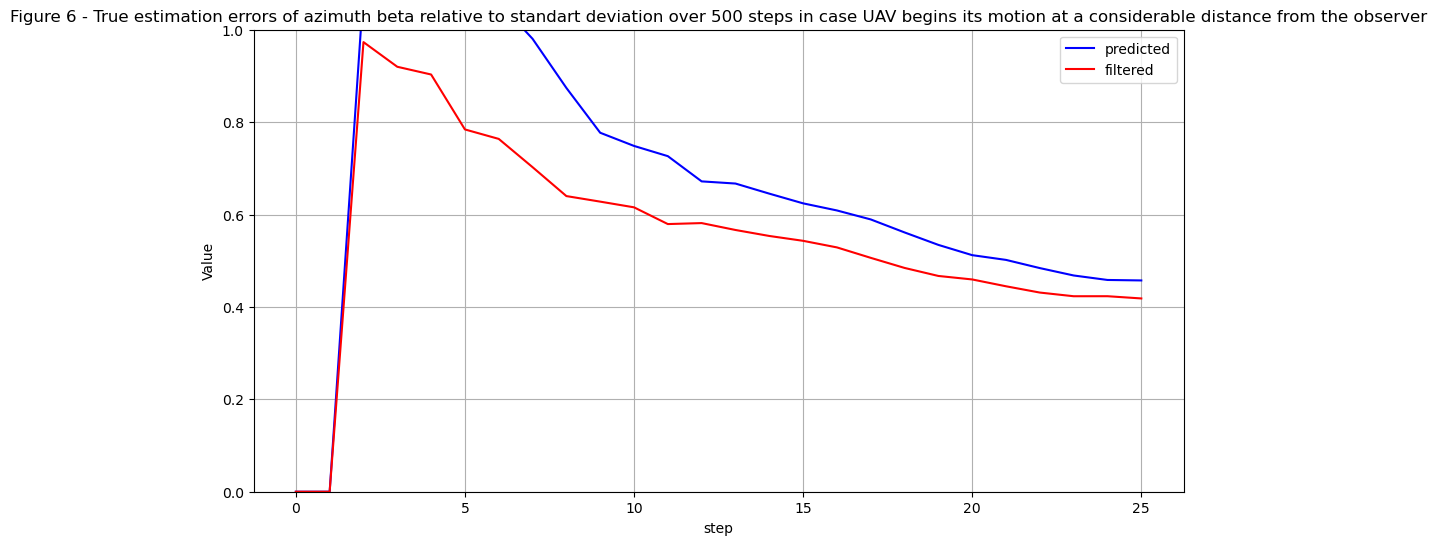

In [14]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errbp, color="blue", label='predicted')
plt.plot(fin_errbf, color="red", label='filtered')
plt.title('Figure 6 - True estimation errors of azimuth beta relative to standart deviation over 500 steps in case UAV begins its motion at a considerable distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.ylim(0,1)
plt.grid()
plt.legend()
plt.show()

Over time, the error for both values ​​decreases. Thus, the filter works efficiently because the value is less than 1 over most of the interval.

Let's plot the true value of $x$ against the true $\beta$ to see if there is a linear relationship.

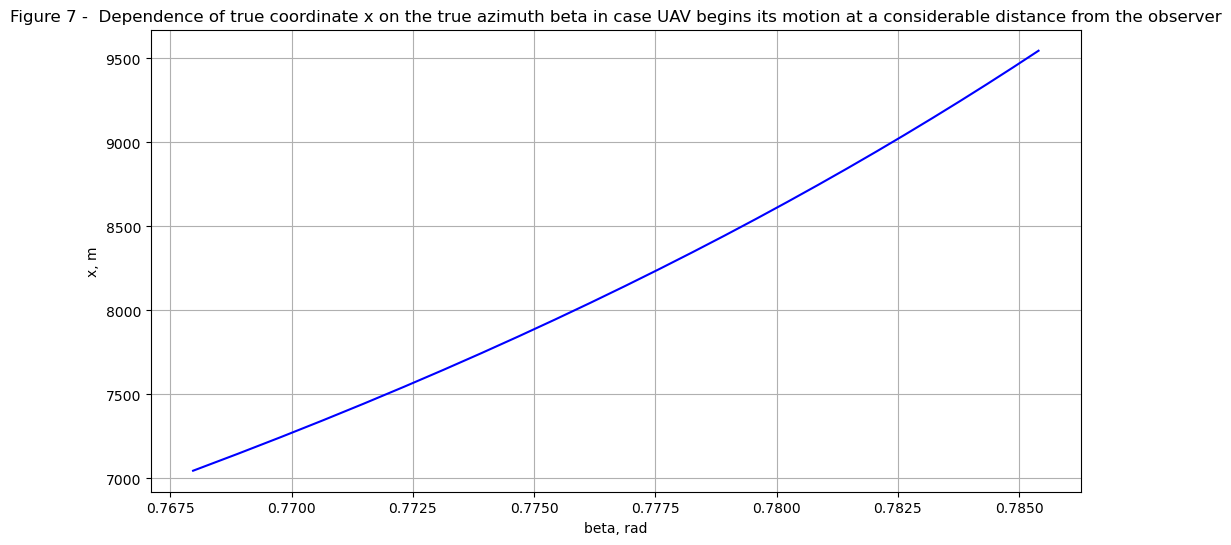

In [15]:
#Plot of x on beta
plt.figure(figsize=(12, 6))
plt.plot(beta_real, x_real, color="blue")
plt.title('Figure 7 -  Dependence of true coordinate x on the true azimuth beta in case UAV begins its motion at a considerable distance from the observer')
plt.xlabel('beta, rad')
plt.ylabel('x, m')
plt.grid()
plt.show()

As we see, dependence is close to linear, that means that the linearization errors are insignificant

Let us calculate the condition number of the covariance matrix $R$ on the interval.

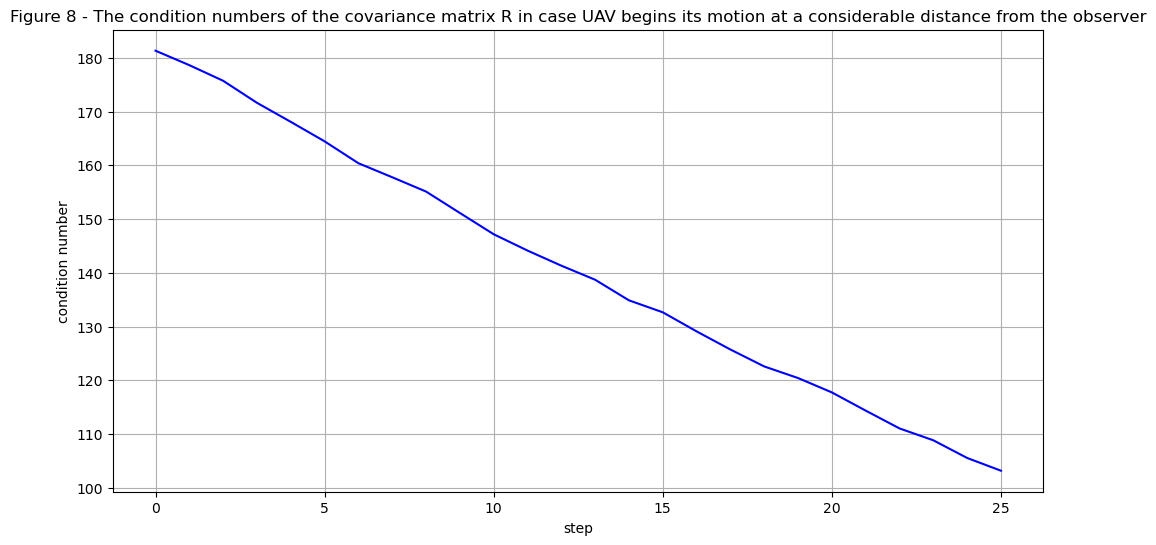

In [16]:
#Plot of condition number
plt.figure(figsize=(12, 6))
plt.plot(np.linalg.cond(R), color="blue")
plt.title('Figure 8 - The condition numbers of the covariance matrix R in case UAV begins its motion at a considerable distance from the observer')
plt.xlabel('step')
plt.ylabel('condition number')
plt.grid()
plt.show()

As we can see, the condition number decrease over time. Thus, the matrix $R$ is well-conditioned.

Let's analyze the gain of the Kalman filter $K$.

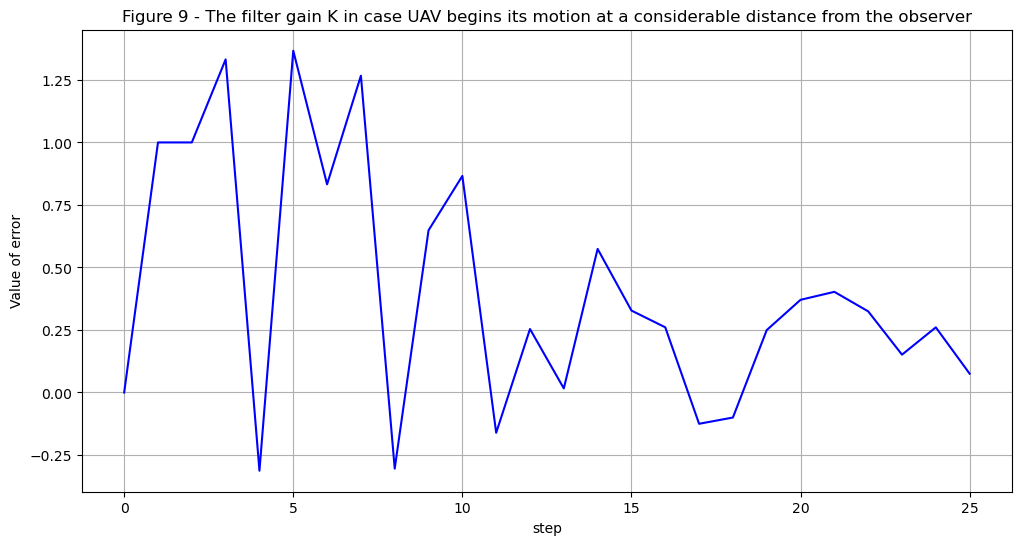

In [17]:
#Plot of condition number
plt.figure(figsize=(12, 6))
plt.plot(K[:,0,0], color="blue")
plt.title('Figure 9 - The filter gain K in case UAV begins its motion at a considerable distance from the observer')
plt.xlabel('step')
plt.ylabel('Value of error')
plt.grid()
plt.show()

As can be seen, the gain mostly fluctuates between 0 and 1. However, at certain points, its values ​​exceed these limits, becoming negative or exceeding unity. This anomaly is the result of a minor linearization error due to the dependence on polar coordinates. The error is small because the object is located far from the observer.

Let's run the Kalman filter again for 500 iterations, but with smaller initial values $x$ and $y$.

$x_0 = \frac{3500}{\sqrt{2}} 𝑚$., $y_0 = \frac{3500}{\sqrt{2}} 𝑚$.

In [18]:
#calculate error
M=500
steps=26
errordp=np.zeros((M,steps))
errorbp=np.zeros((M,steps))
fin_errdp=np.zeros(steps)
fin_errbp=np.zeros(steps)
errordf=np.zeros((M,steps))
errorbf=np.zeros((M,steps))
fin_errdf=np.zeros(steps)
fin_errbf=np.zeros(steps)
gain=np.zeros((M,steps))
fin_gain = np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=26
    x_real=np.zeros(steps)
    vx_real=np.zeros(steps)
    y_real=np.zeros(steps)
    vy_real=np.zeros(steps)
    t=2
    x_real[0]=3500/(sqrt(2))
    y_real[0]=3500/(sqrt(2))
    vx_real[0]=-50
    vy_real[0]=-45
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+vx_real[i-1]*t
        vx_real[i]=vx_real[i-1]
        y_real[i]=y_real[i-1]+vy_real[i-1]*t
        vy_real[i]=vy_real[i-1]
    #trajectory_in_polar_coordinate_system
    D_real=np.zeros(steps)
    beta_real=np.zeros(steps)
    for i in range(0,steps):
        D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
        beta_real[i] = atan(x_real[i]/y_real[i])
    #generating_measurements_of_polar
    D=np.zeros(steps)
    beta=np.zeros(steps)
    for i in range(0,steps):
        D[i]=D_real[i]+np.random.normal(0,20)
        beta[i]=beta_real[i]+np.random.normal(0,0.02)
    x=np.zeros(steps)
    y=np.zeros(steps)
    for i in range(0,steps):
        x[i]=D[i]*sin(beta[i])
        y[i]=D[i]*cos(beta[i])
    z = np.zeros((len(x), 2, 1))
    for i in range(len(x)):
        z[i] = np.array([[x[i]], [y[i]]])
    #transition matrix
    fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
    #observation matrix
    h=np.matrix([[1,0,0,0],[0,0,1,0]])
    #state vector
    X = np.zeros((len(x_real), 4, 1))
    #Initial filtered estimate
    X[0]=np.matrix([[40000],[-20],[40000],[-20]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 4, 4))
    P[0]=np.matrix([[10**10, 0,0,0], [0, 10**10,0,0],[0,0,10**10,0],[0,0,0,10**10]])
    D_pred=np.zeros(steps)
    D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_pred=np.zeros(steps)
    beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
    D_filt=np.zeros(steps)
    D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_filt=np.zeros(steps)
    beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
    #Covariance matrix
    R=np.zeros((steps, 2, 2))
    for i in range(0,steps):
        R[i]=np.matrix([[sin(beta[i])**2 * 20**2 + D[i]**2 *cos(beta[i])**2*0.02**2, sin(beta[i])*cos(beta[i])*(20**2-D[i]**2*0.02**2)], [sin(beta[i])*cos(beta[i])*(20**2-D[i]**2*0.02**2), cos(beta[i])**2*20**2+D[i]**2*sin(beta[i])**2*0.02**2]])
    for i in range(1,steps):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)
        D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
        #step of filtration
        E=h@P[i]@h.T + R[i]
        K[i]=P[i]@h.T@np.linalg.inv(E)
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(4)-K[i]@h)@P[i]
        D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
        gain[o, i] = K[i, 0, 0]
    for k in range(2,steps):
        errordp[o,k]=(D_real[k]-D_pred[k])**2
        errorbp[o,k]=(beta_real[k]-beta_pred[k])**2
        errordf[o,k]=(D_real[k]-D_filt[k])**2
        errorbf[o,k]=(beta_real[k]-beta_filt[k])**2
for i in range(steps):
    for j in range(M):
        fin_gain[i] += gain[j, i]/M
        fin_errdp[i]=fin_errdp[i]+((1/(M-1))*errordp[j,i])
        fin_errbp[i]=fin_errbp[i]+((1/(M-1))*errorbp[j,i])
        fin_errdf[i]=fin_errdf[i]+((1/(M-1))*errordf[j,i])
        fin_errbf[i]=fin_errbf[i]+((1/(M-1))*errorbf[j,i])
    fin_errdp[i]=sqrt(fin_errdp[i])/20
    fin_errbp[i]=sqrt(fin_errbp[i])/0.02
    fin_errdf[i]=sqrt(fin_errdf[i])/20
    fin_errbf[i]=sqrt(fin_errbf[i])/0.02

Let's plot the polar plot of all values

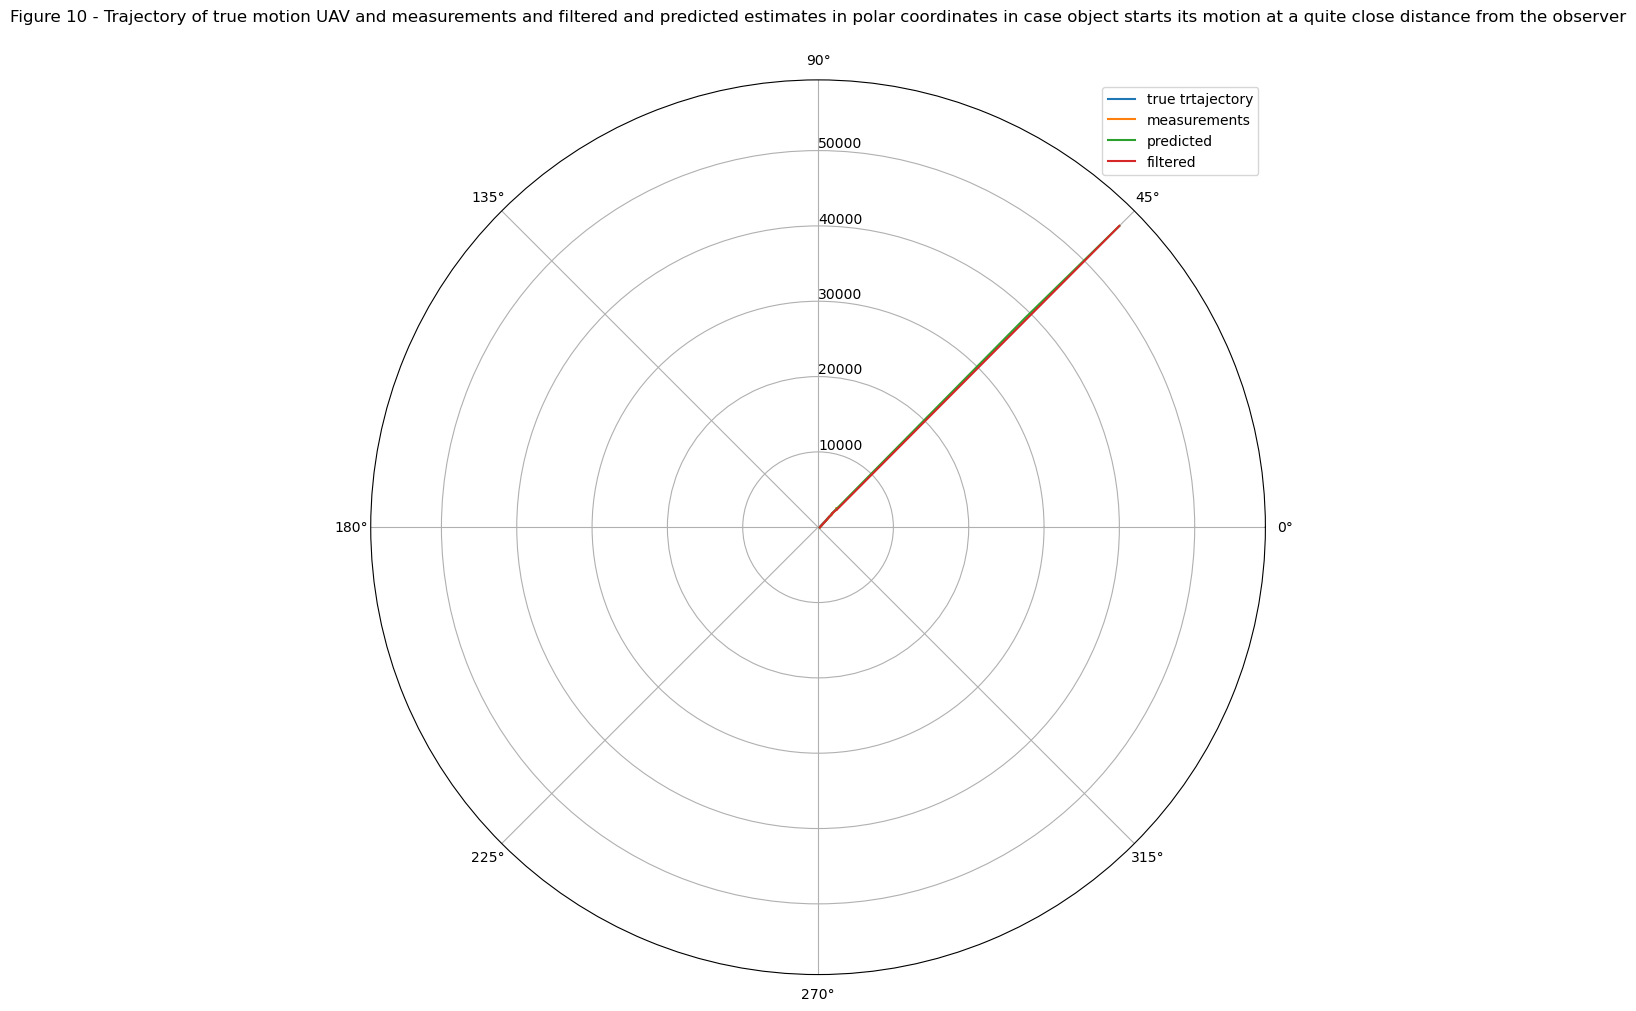

In [19]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_rlabel_position(90) 
ax.set_title("Figure 10 - Trajectory of true motion UAV and measurements and filtered and predicted estimates in polar coordinates in case object starts its motion at a quite close distance from the observer", va='bottom',pad=40)
plt.show()

Let's zoom-in a plot

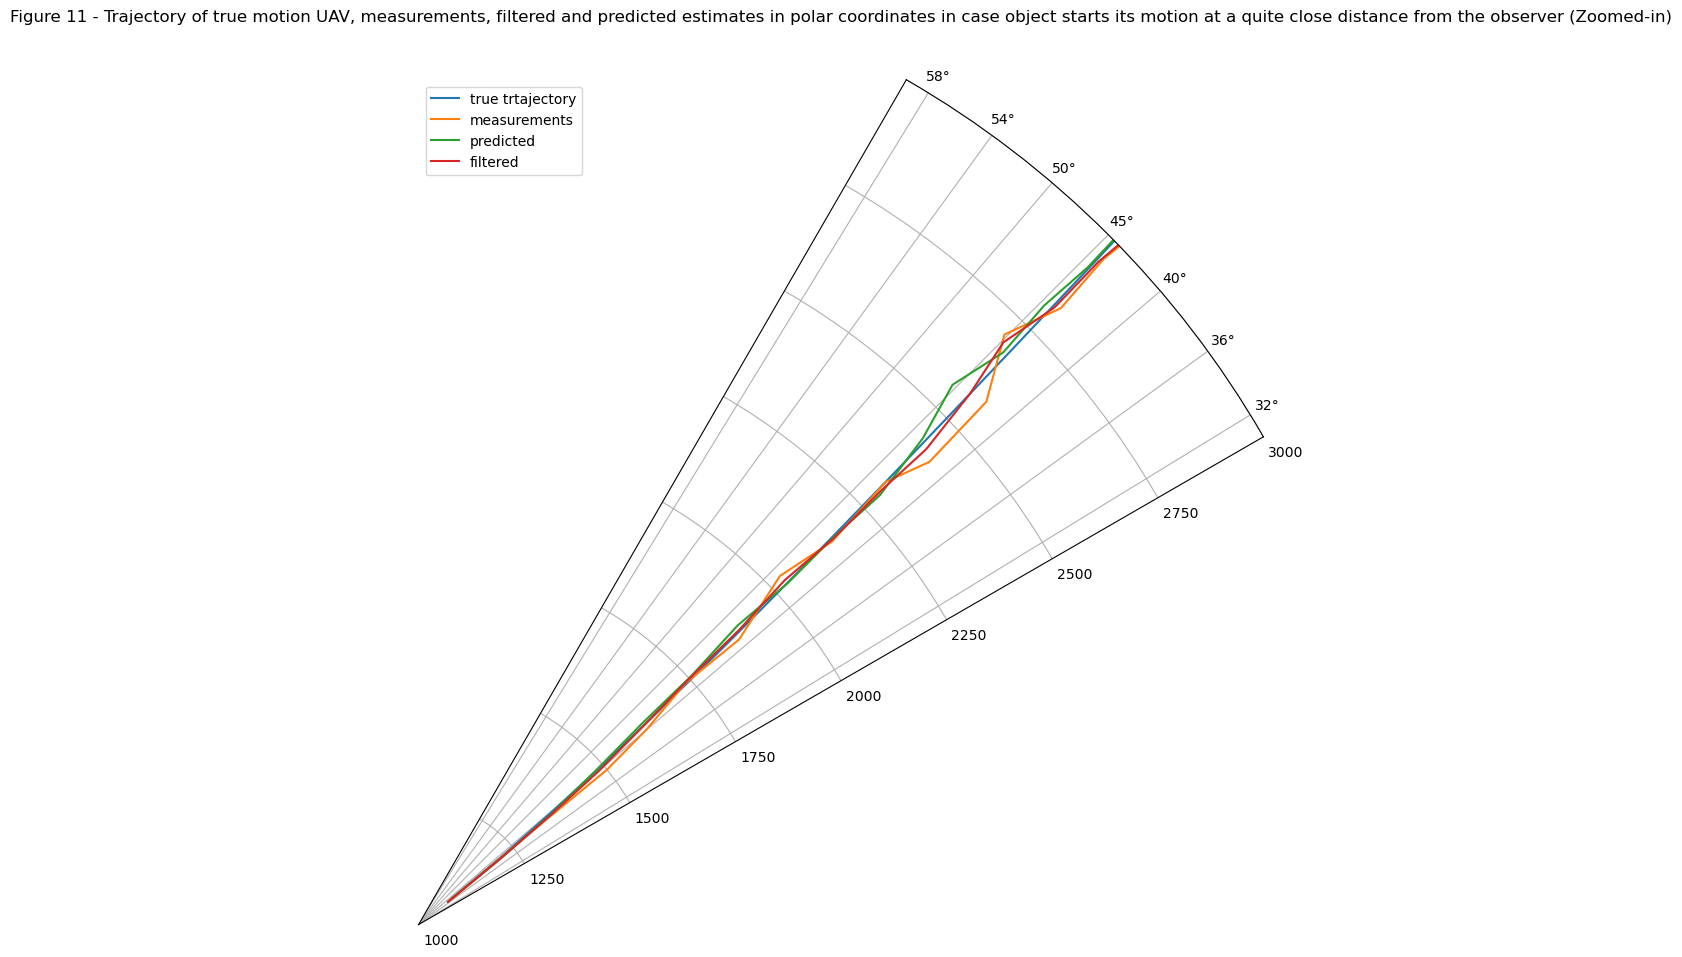

In [20]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_ylim(1000,3000)
ax.set_xlim(pi/6,pi/3)
ax.set_rlabel_position(90) 
ax.set_title("Figure 11 - Trajectory of true motion UAV, measurements, filtered and predicted estimates in polar coordinates in case object starts its motion at a quite close distance from the observer (Zoomed-in)", va='bottom',pad=40)
plt.show()

As we can see, the Kalman filter works worse in case object starts its motion at a quite close distance from the observer.

Let's analyze the gain of the Kalman filter $K$.

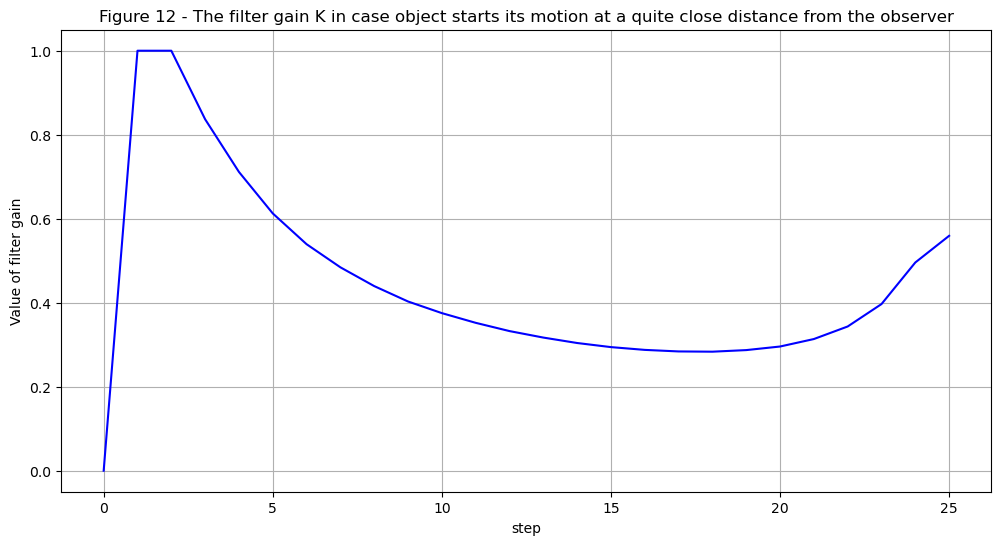

In [21]:
#Plot of condition number
plt.figure(figsize=(12, 6))
plt.plot(fin_gain, color="blue")
plt.title('Figure 12 - The filter gain K in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value of filter gain')
plt.grid()
plt.show()

We see that the filter gain has stopped being stable. As we can see, at first the gain matrix value falls into the range from 0 to 1, but as we approach the observer, the gain begins to grow, since the matrix R depends on the polar coordinates, in which the error increases as we approach the observer.

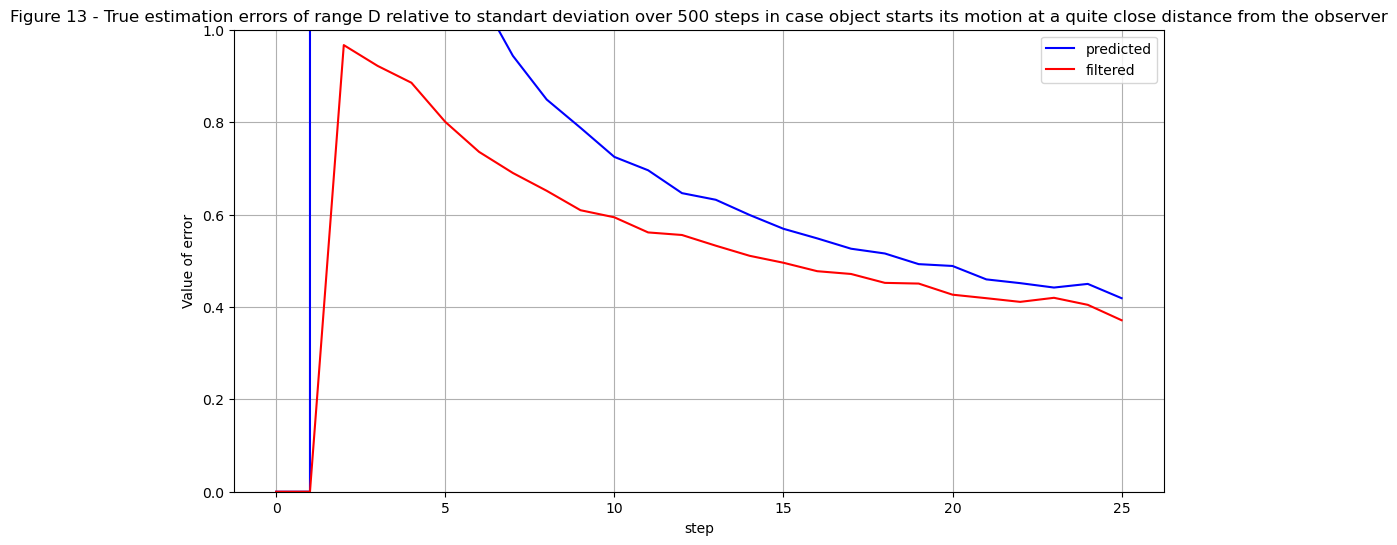

In [22]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errdp, color="blue", label='predicted')
plt.plot(fin_errdf, color="red", label='filtered')
plt.title('Figure 13 - True estimation errors of range D relative to standart deviation over 500 steps in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value of error')
plt.ylim(0,1)
plt.grid()
plt.legend()
plt.show()

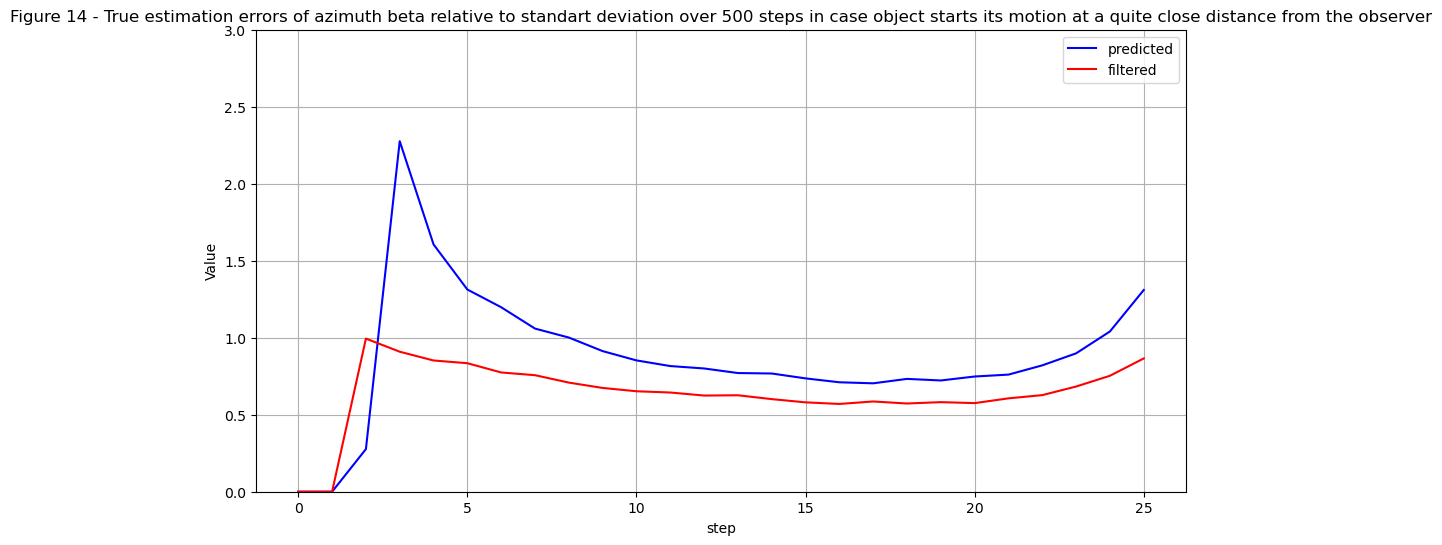

In [23]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errbp, color="blue", label='predicted')
plt.plot(fin_errbf, color="red", label='filtered')
plt.title('Figure 14 - True estimation errors of azimuth beta relative to standart deviation over 500 steps in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.ylim(0,3)
plt.grid()
plt.legend()
plt.show()

As we can see, the error begins to increase as we approach the observer. Initially, it decreases, but as we approach it increases. Moreover, the errrors of azimuth increased, but errors of range D remained the same. As the object approached the observer, the azimuth error began to diverge slightly due to non-linearity.

Let's plot the true value of $x$ against the true $\beta$ to see if there is a linear relationship.

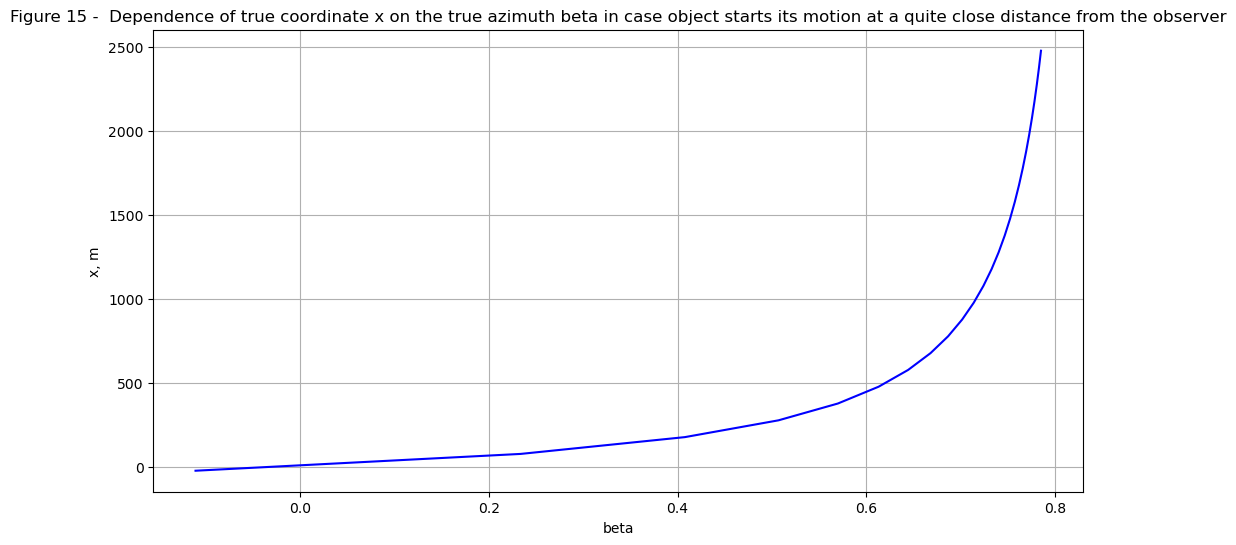

In [24]:
#Plot of x on beta
plt.figure(figsize=(12, 6))
plt.plot(beta_real, x_real, color="blue")
plt.title('Figure 15 -  Dependence of true coordinate x on the true azimuth beta in case object starts its motion at a quite close distance from the observer')
plt.xlabel('beta')
plt.ylabel('x, m')
plt.grid()
plt.show()

As we can see, the dependence remains linear in a certain range, but as the distance decreases, it becomes nonlinear. That is, linearization errors are significant, which degrades the quality of filtration.

Let us calculate the condition number of the covariance matrix $R$ on the interval.

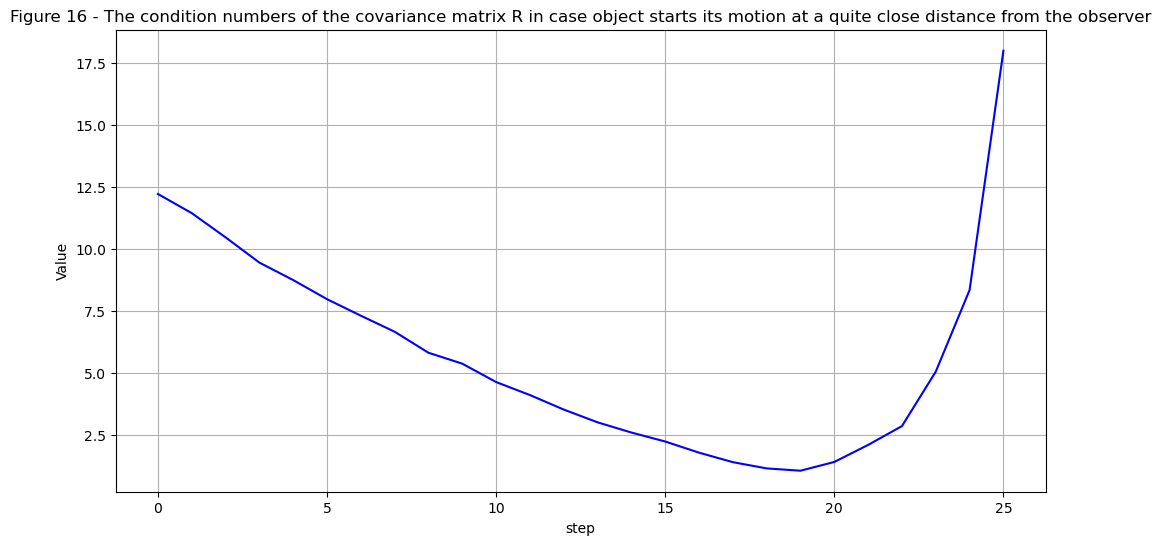

In [25]:
#Plot of condition number
plt.figure(figsize=(12, 6))
plt.plot(np.linalg.cond(R), color="blue")
plt.title('Figure 16 - The condition numbers of the covariance matrix R in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.grid()
plt.show()

As we can see, the condition number initially decreases, but as it gets closer to the observer, it begins to increase rapidly due to the non-linearity of the coordinate transformation. But so as, condition number is more close to 1, than 1000, our matrix R is well-conditioned.

Thus, we saw that linearization errors significantly impact filtering accuracy, significantly worsening the filtering performance. We also noticed that the closer the object is to the observer, the worse the filtering performance becomes, significantly reducing the quality.

Let's run the Kalman filter again for 500 iterations, but with different values $\sigma _{D}$ and $\sigma _{\beta}$.

$\sigma _{D}$=50 m and $\sigma _{\beta}$ = 0.0015 rad

In [26]:
#calculate error
M=500
steps=26
errordp=np.zeros((M,steps))
errorbp=np.zeros((M,steps))
fin_errdp=np.zeros(steps)
fin_errbp=np.zeros(steps)
errordf=np.zeros((M,steps))
errorbf=np.zeros((M,steps))
fin_errdf=np.zeros(steps)
fin_errbf=np.zeros(steps)
gain=np.zeros((M,steps))
fin_gain = np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=26
    x_real=np.zeros(steps)
    vx_real=np.zeros(steps)
    y_real=np.zeros(steps)
    vy_real=np.zeros(steps)
    t=2
    x_real[0]=3500/(sqrt(2))
    y_real[0]=3500/(sqrt(2))
    vx_real[0]=-50
    vy_real[0]=-45
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+vx_real[i-1]*t
        vx_real[i]=vx_real[i-1]
        y_real[i]=y_real[i-1]+vy_real[i-1]*t
        vy_real[i]=vy_real[i-1]
    #trajectory_in_polar_coordinate_system
    D_real=np.zeros(steps)
    beta_real=np.zeros(steps)
    for i in range(0,steps):
        D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
        beta_real[i] = atan(x_real[i]/y_real[i])
    #generating_measurements_of_polar
    D=np.zeros(steps)
    beta=np.zeros(steps)
    for i in range(0,steps):
        D[i]=D_real[i]+np.random.normal(0,50)
        beta[i]=beta_real[i]+np.random.normal(0,0.0015)
    x=np.zeros(steps)
    y=np.zeros(steps)
    for i in range(0,steps):
        x[i]=D[i]*sin(beta[i])
        y[i]=D[i]*cos(beta[i])
    z = np.zeros((len(x), 2, 1))
    for i in range(len(x)):
        z[i] = np.array([[x[i]], [y[i]]])
    #transition matrix
    fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
    #observation matrix
    h=np.matrix([[1,0,0,0],[0,0,1,0]])
    #state vector
    X = np.zeros((len(x_real), 4, 1))
    #Initial filtered estimate
    X[0]=np.matrix([[40000],[-20],[40000],[-20]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 4, 4))
    P[0]=np.matrix([[10**10, 0,0,0], [0, 10**10,0,0],[0,0,10**10,0],[0,0,0,10**10]])
    D_pred=np.zeros(steps)
    D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_pred=np.zeros(steps)
    beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
    D_filt=np.zeros(steps)
    D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_filt=np.zeros(steps)
    beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
    #Covariance matrix
    R=np.zeros((steps, 2, 2))
    for i in range(0,steps):
        R[i]=np.matrix([[sin(beta[i])**2*50**2+D[i]**2*cos(beta[i])**2*0.0015**2,sin(beta[i])*cos(beta[i])*(50**2-D[i]**2*0.0015**2)],[sin(beta[i])*cos(beta[i])*(50**2-D[i]**2*0.0015**2), (cos(beta[i]))**2*50**2+D[i]**2*sin(beta[i])**2*0.0015**2]])
    K = np.zeros((steps, 4, 2))
    for i in range(1,steps):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)
        D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
        #step of filtration
        E=h@P[i]@h.T + R[i]
        K[i]=P[i]@h.T@np.linalg.inv(E)
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(4)-K[i]@h)@P[i]
        D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
        gain[o, i] = K[i, 0, 0]
    for k in range(2,steps):
        errordp[o,k]=(D_real[k]-D_pred[k])**2
        errorbp[o,k]=(beta_real[k]-beta_pred[k])**2
        errordf[o,k]=(D_real[k]-D_filt[k])**2
        errorbf[o,k]=(beta_real[k]-beta_filt[k])**2
for i in range(steps):
    for j in range(M):
        fin_gain[i] += gain[j, i]/M
        fin_errdp[i]=fin_errdp[i]+((1/(M-1))*errordp[j,i])
        fin_errbp[i]=fin_errbp[i]+((1/(M-1))*errorbp[j,i])
        fin_errdf[i]=fin_errdf[i]+((1/(M-1))*errordf[j,i])
        fin_errbf[i]=fin_errbf[i]+((1/(M-1))*errorbf[j,i])
    fin_errdp[i]=sqrt(fin_errdp[i])/50
    fin_errbp[i]=sqrt(fin_errbp[i])/0.0015
    fin_errdf[i]=sqrt(fin_errdf[i])/50
    fin_errbf[i]=sqrt(fin_errbf[i])/0.0015

Let's plot the polar plot of all values

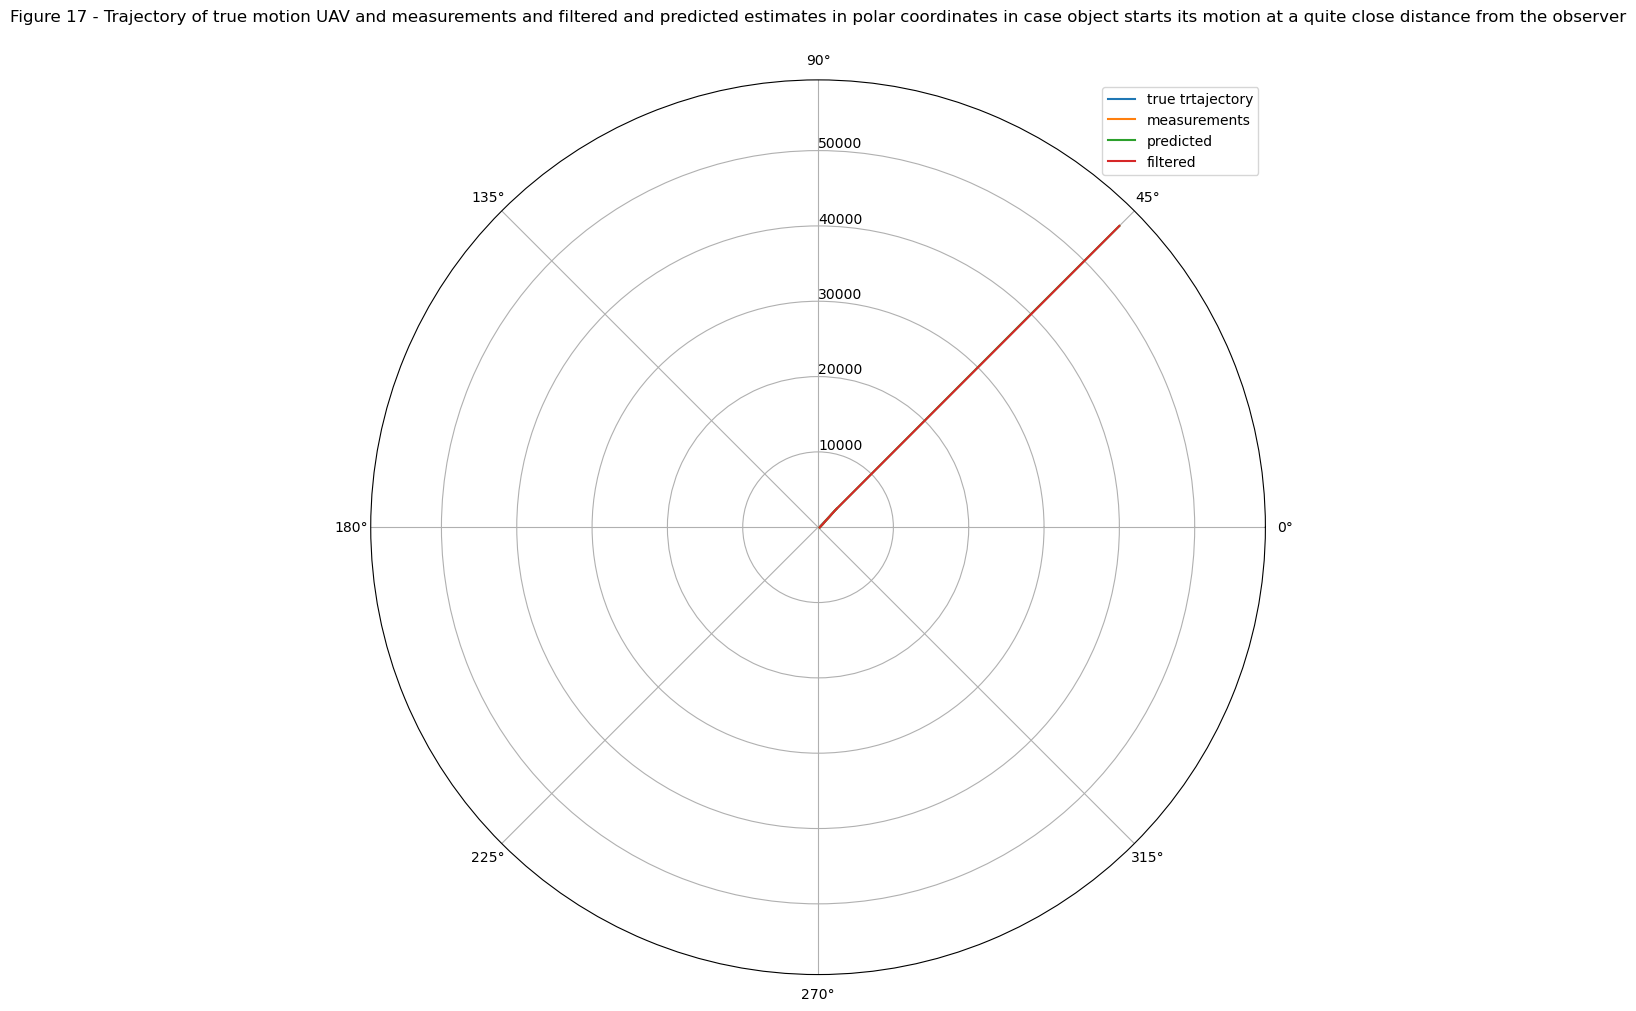

In [27]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_rlabel_position(90) 
ax.set_title("Figure 17 - Trajectory of true motion UAV and measurements and filtered and predicted estimates in polar coordinates in case object starts its motion at a quite close distance from the observer", va='bottom',pad=40)
plt.show()

Let's zoom-in a plot

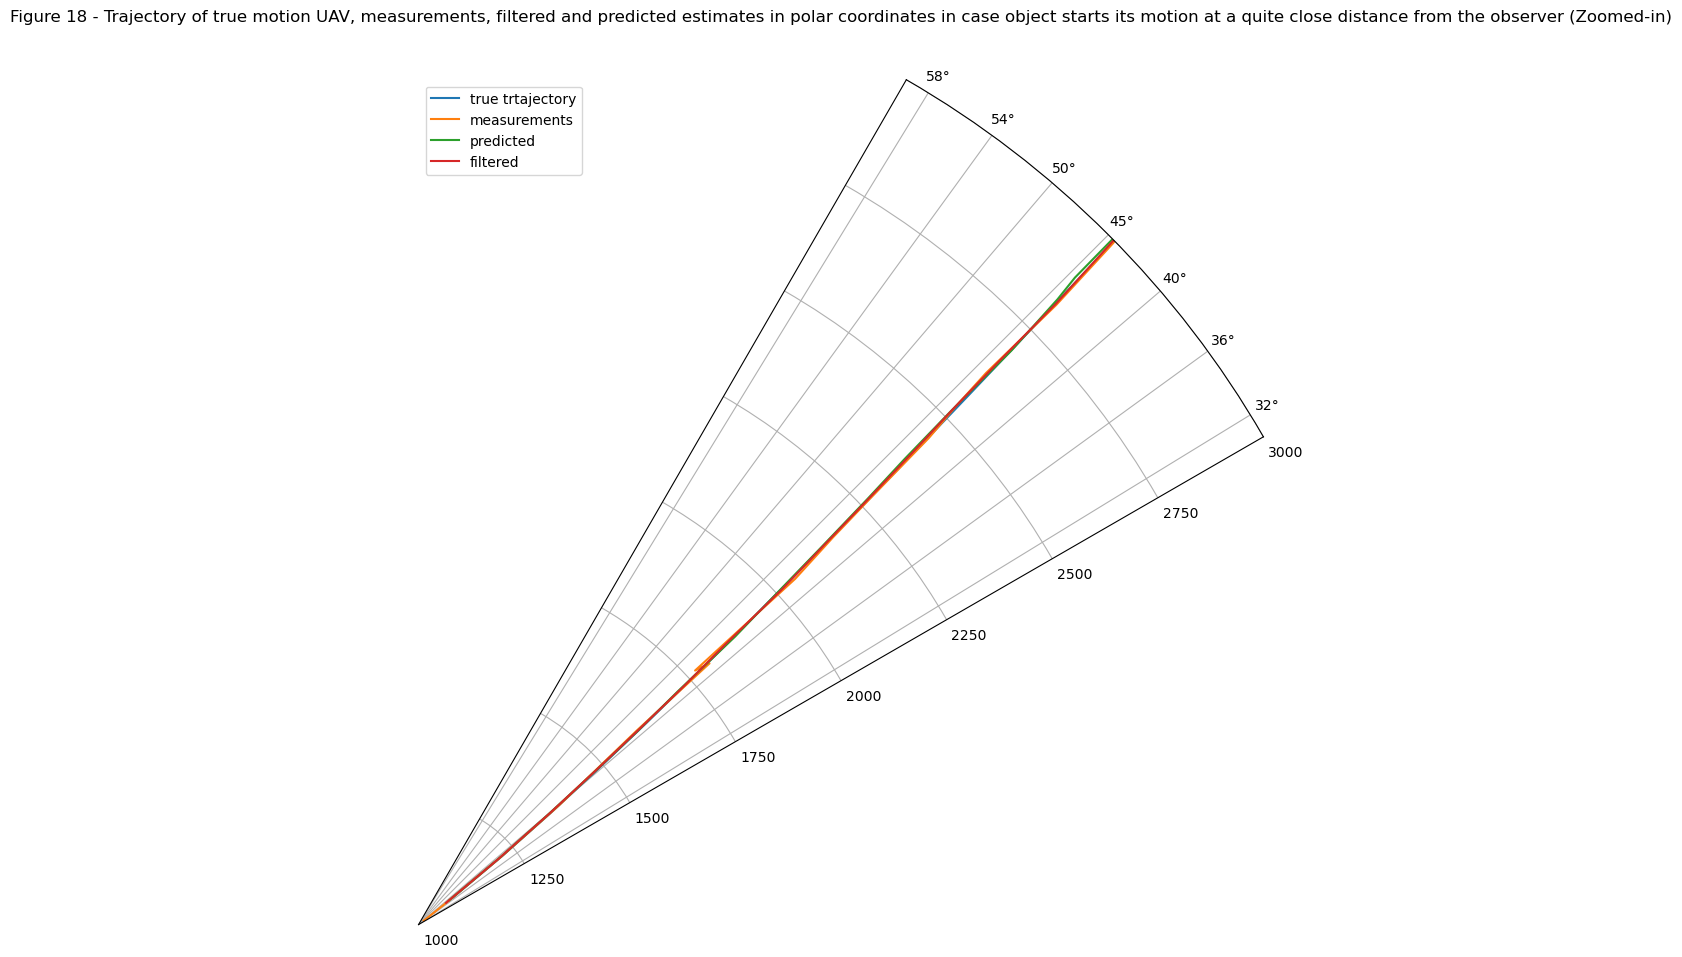

In [28]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_ylim(1000,3000)
ax.set_xlim(pi/6,pi/3)
ax.set_rlabel_position(90) 
ax.set_title("Figure 18 - Trajectory of true motion UAV, measurements, filtered and predicted estimates in polar coordinates in case object starts its motion at a quite close distance from the observer (Zoomed-in)", va='bottom',pad=40)
plt.show()

As we can see from visual representation, the quality has gotten better, but we should check real errors.

Let's analyze the gain of the Kalman filter $K$.

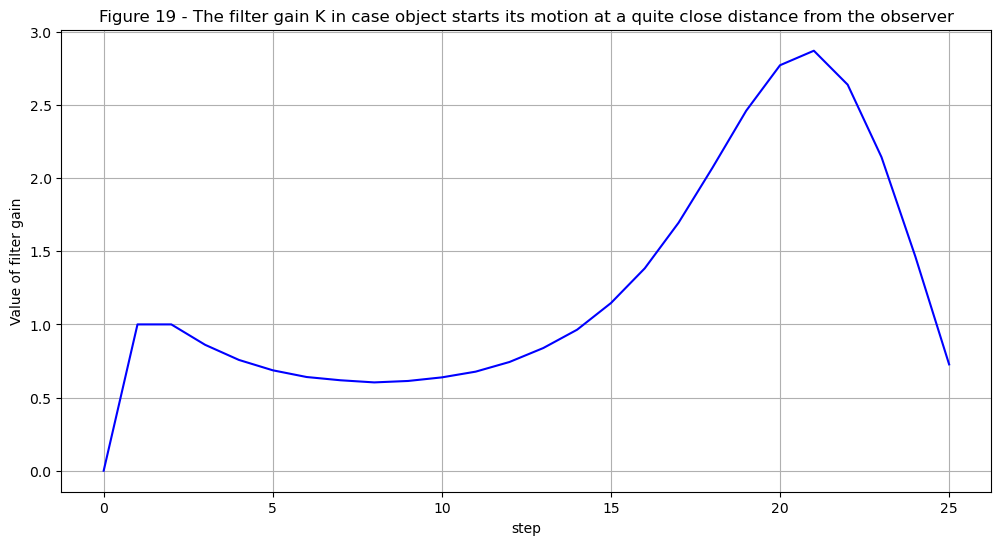

In [29]:
#Plot of condition number
plt.figure(figsize=(12, 6))
plt.plot(fin_gain, color="blue")
plt.title('Figure 19 - The filter gain K in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value of filter gain')
plt.grid()
plt.show()

As we see, at first the value of the gain matrix falls within the range from 0 to 1, but as we approach the observer, gain starts to grow and reaches values greater than 1, since the matrix R depends on polar coordinates, in which the error increases as we approach the observer.

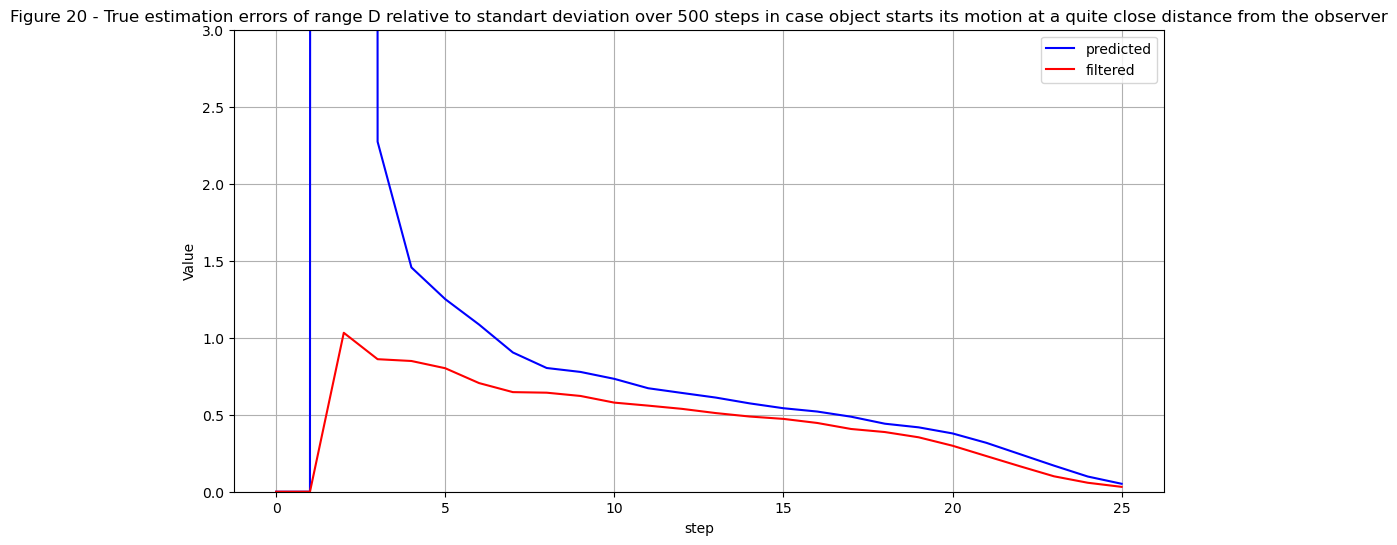

In [30]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errdp, color="blue", label='predicted')
plt.plot(fin_errdf, color="red", label='filtered')
plt.title('Figure 20 - True estimation errors of range D relative to standart deviation over 500 steps in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.ylim(0,3)
plt.grid()
plt.legend()
plt.show()

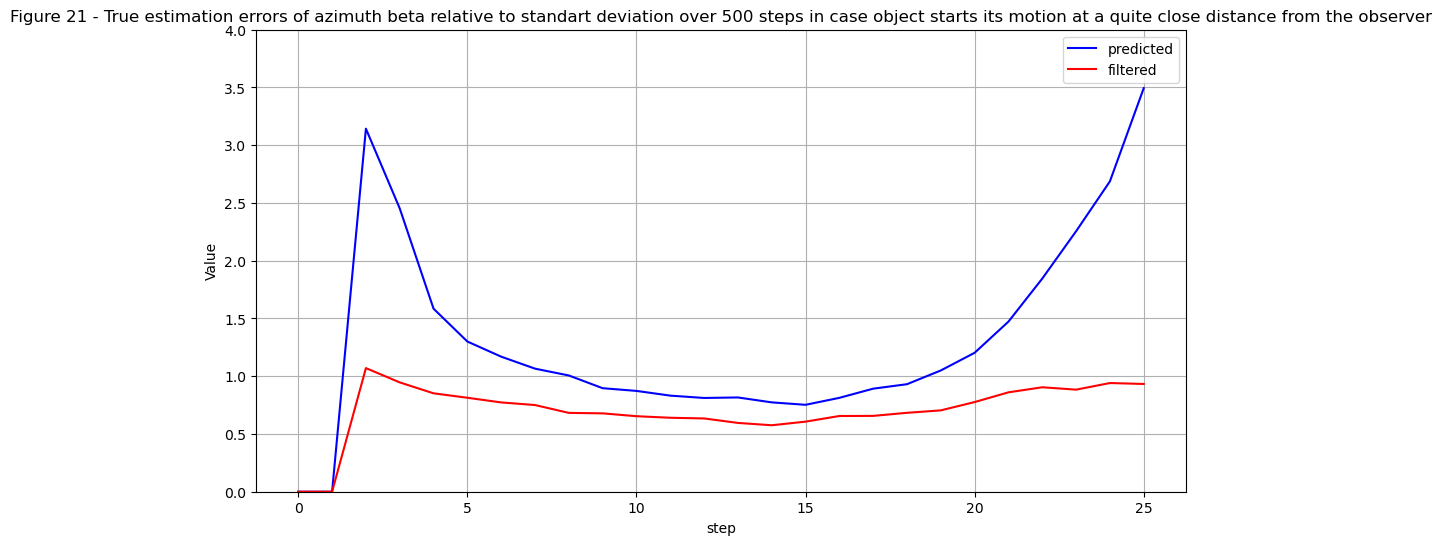

In [31]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errbp, color="blue", label='predicted')
plt.plot(fin_errbf, color="red", label='filtered')
plt.title('Figure 21 - True estimation errors of azimuth beta relative to standart deviation over 500 steps in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.ylim(0,4)
plt.grid()
plt.legend()
plt.show()

As we can see, the error begins to increase as we approach the observer due to the non-linearity of the coordinate transformation. True estimation errors of range D relative to standard deviation decreased, while true estimation errors of azimuth beta relative to standard deviation increased. The azimuth error began to diverge.

Let's plot the true value of $x$ against the true $\beta$ to see if there is a linear relationship.

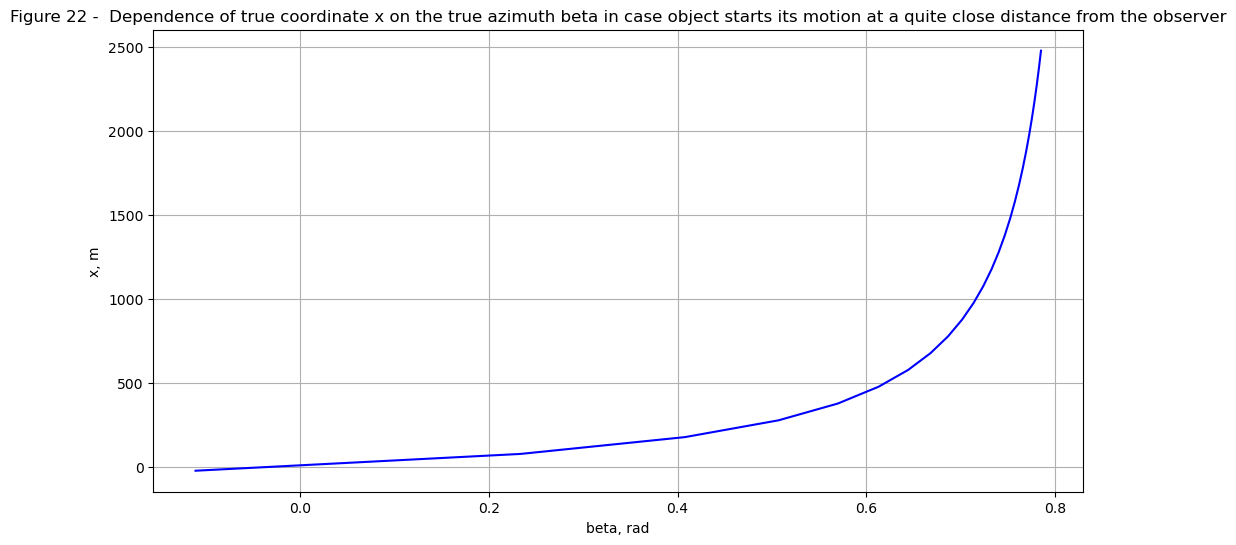

In [32]:
#Plot of x on beta
plt.figure(figsize=(12, 6))
plt.plot(beta_real, x_real, color="blue")
plt.title('Figure 22 -  Dependence of true coordinate x on the true azimuth beta in case object starts its motion at a quite close distance from the observer')
plt.xlabel('beta, rad')
plt.ylabel('x, m')
plt.grid()
plt.show()

As we can see, the dependence is nonlinear, that is, linearization errors are significant, which degrades the quality of filtration.

Let us calculate the condition number of the covariance matrix 
 on the interval.

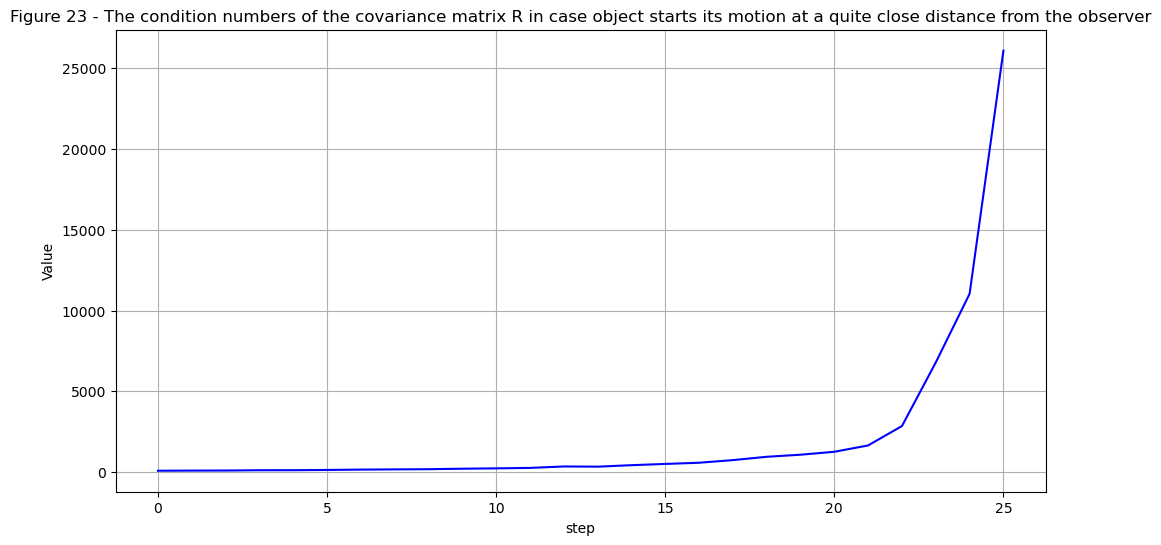

In [33]:
#Plot of condition number
plt.figure(figsize=(12, 6))
plt.plot(np.linalg.cond(R), color="blue")
plt.title('Figure 23 - The condition numbers of the covariance matrix R in case object starts its motion at a quite close distance from the observer')
plt.xlabel('step')
plt.ylabel('Value')
plt.grid()
plt.show()

As we can see, the condition number is large and only increases over time, meaning that the matrix $R$ is ill-conditioned.

**Conclusion:**

Thus, when the coordinates are close to the observer and the condition number is unsuitable, the navigation system becomes blind, because although we can determine the distance, our azimuth estimate diverges. Based on the fact that we cannot accurately determine the azimuth, we cease to know the position in cartesian coordinates. Thus, it can be concluded that setting the condition number and the non-linearity of the coordinate transformation play a significant role in the operation of the Kalman filter and require a careful approach to setting this parameter. In the latter case, linearization errors were also observed, which also affected the filtration quality, and the $R$ matrix became poorly conditioned.

**Learning log:**

What we learned:

We explored working with polar coordinates and applying the Kalman filter to different measurements and motion models. We also examined how the object's proximity to the observer affects the quality of the filtering, as well as how the condition number affects different object locations relative to the observer.

What difficulties I faced:

We faced the challenge of understanding how to properly adjust the condition number when an object is close to the observer, as well as how transforming from one coordinate system to another affects the filtering quality. It was difficult to analyze the error ratio in different cases. It was also difficult to analyze the behavior of the filter gain in the case when it became more than 1